# EDA v2 Render Profile Check

이 노트북은 `src_v2_0.edav2_profile`로 샘플링된 촬영 구도, 조명, 밝기/채도 보정이 실제 preview 이미지에 어떻게 반영되는지 빠르게 확인합니다.

In [1]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.dpi'] = 140
pd.set_option('display.max_columns', 200)

ROOT = Path.cwd()
if (ROOT / 'tools' / 'simulator').exists():
    REPO_ROOT = ROOT
elif ROOT.name == 'simulator' and (ROOT.parent.parent / 'tools' / 'simulator').exists():
    REPO_ROOT = ROOT.parent.parent
else:
    REPO_ROOT = ROOT.parent

SIM_DIR = REPO_ROOT / 'tools' / 'simulator'
for path in [str(REPO_ROOT), str(SIM_DIR)]:
    if path not in sys.path:
        sys.path.insert(0, path)

import src_v2_0.preview as preview_mod
import src_v2_0.edav2_profile as profile_mod
from src_v2_0.preview import render_structure_preview

preview_mod = importlib.reload(preview_mod)
profile_mod = importlib.reload(profile_mod)

CLASS_ORDER = [
    'thin tower',
    'thick tower',
    'wall',
    'thin triangle',
    'thick triangle',
    'double triangle',
    'pyramid',
]

print({'repo_root': str(REPO_ROOT), 'sim_dir': str(SIM_DIR)})

{'repo_root': 'd:\\Downloads\\open', 'sim_dir': 'd:\\Downloads\\open\\tools\\simulator'}


In [2]:
def image_metrics(rgb: np.ndarray) -> dict:
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    return {
        'brightness_mean': float(hsv[:, :, 2].mean() / 255.0),
        'saturation_mean': float(hsv[:, :, 1].mean() / 255.0),
    }


def flatten_profile(profile: dict) -> dict:
    front_cam = profile['front_camera']
    top_cam = profile['top_camera']
    front_pose = profile.get('front_pose', {})
    top_pose = profile.get('top_pose', {})
    light = profile['light']
    front_tone = profile['front_tone']
    top_tone = profile['top_tone']
    return {
        'front_yaw_deg': front_pose.get('yaw_deg'),
        'front_pitch_deg': front_pose.get('pitch_deg'),
        'front_roll_deg': front_pose.get('roll_deg'),
        'front_radius': front_pose.get('radius'),
        'front_height_boost': front_pose.get('height_boost'),
        'front_eye_x': front_cam['eye'][0],
        'front_eye_y': front_cam['eye'][1],
        'front_eye_z': front_cam['eye'][2],
        'front_target_z': front_cam['target'][2],
        'front_fov': front_cam['fov'],
        'top_roll_deg': top_pose.get('roll_deg'),
        'top_eye_x': top_cam['eye'][0],
        'top_eye_y': top_cam['eye'][1],
        'top_eye_z': top_cam['eye'][2],
        'top_fov': top_cam['fov'],
        'light_dir_x': light['direction'][0],
        'light_dir_y': light['direction'][1],
        'light_dir_z': light['direction'][2],
        'light_color': light['color'][0],
        'front_sat_gain': front_tone['saturation_gain'],
        'front_val_gain': front_tone['value_gain'],
        'top_sat_gain': top_tone['saturation_gain'],
        'top_val_gain': top_tone['value_gain'],
    }


def preview_case(structure: str, stability: str, seed: int = 42):
    preview = render_structure_preview(
        seed=seed,
        structure=structure,
        stability_label=stability,
        relaxed=True,
        gui=False,
    )
    front_metrics = image_metrics(preview.front_rgb)
    top_metrics = image_metrics(preview.top_rgb)
    return preview, front_metrics, top_metrics


def summarize_cases(structure: str, stability: str, seeds=range(8)) -> pd.DataFrame:
    rows = []
    previews = []
    for seed in seeds:
        preview, front_metrics, top_metrics = preview_case(structure, stability, seed=seed)
        row = {
            'seed': seed,
            'structure': structure,
            'stability': stability,
            **flatten_profile(preview.render_profile),
            'front_brightness_mean': front_metrics['brightness_mean'],
            'front_saturation_mean': front_metrics['saturation_mean'],
            'top_brightness_mean': top_metrics['brightness_mean'],
            'top_saturation_mean': top_metrics['saturation_mean'],
        }
        rows.append(row)
        previews.append(preview)
    return pd.DataFrame(rows), previews


def show_previews(previews, max_items: int = 6):
    n = min(len(previews), max_items)
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
    if n == 1:
        axes = np.array([axes])
    for idx in range(n):
        preview = previews[idx]
        axes[idx, 0].imshow(preview.front_rgb)
        axes[idx, 0].set_title(f'front | seed={idx}')
        axes[idx, 0].axis('off')
        axes[idx, 1].imshow(preview.top_rgb)
        axes[idx, 1].set_title(f'top | seed={idx}')
        axes[idx, 1].axis('off')
    plt.tight_layout()


EDA_TARGETS = pd.DataFrame([
    {'view': 'front', 'metric': 'brightness_mean', 'target_mean': 0.826, 'notes': 'dev/test proxy'},
    {'view': 'front', 'metric': 'saturation_mean', 'target_mean': 0.154, 'notes': 'dev/test proxy'},
    {'view': 'top', 'metric': 'brightness_mean', 'target_mean': 0.846, 'notes': 'dev/test proxy'},
    {'view': 'top', 'metric': 'saturation_mean', 'target_mean': 0.151, 'notes': 'dev/test proxy'},
])
EDA_TARGETS

,view,metric,target_mean,notes
0,front,brightness_mean,0.826,dev/test proxy
1,front,saturation_mean,0.154,dev/test proxy
2,top,brightness_mean,0.846,dev/test proxy
3,top,saturation_mean,0.151,dev/test proxy


,front_yaw_deg,front_pitch_deg,front_roll_deg,front_radius,front_height_boost,front_eye_x,front_eye_y,front_eye_z,front_target_z,front_fov,top_roll_deg,top_eye_x,top_eye_y,top_eye_z,top_fov,light_dir_x,light_dir_y,light_dir_z,light_color,front_sat_gain,front_val_gain,top_sat_gain,top_val_gain,front_brightness_mean,front_saturation_mean,top_brightness_mean,top_saturation_mean
0,168.0196,12.7009,-3.4571,7.0197,0.8565,-6.6201,1.4771,3.1226,0.7228,44.8051,-2.4384,-0.0907,-0.0213,8.9111,37.3491,-0.6642,0.2967,0.6861,0.918,1.3797,0.9524,1.166,0.914,0.7901,0.1627,0.7344,0.1778


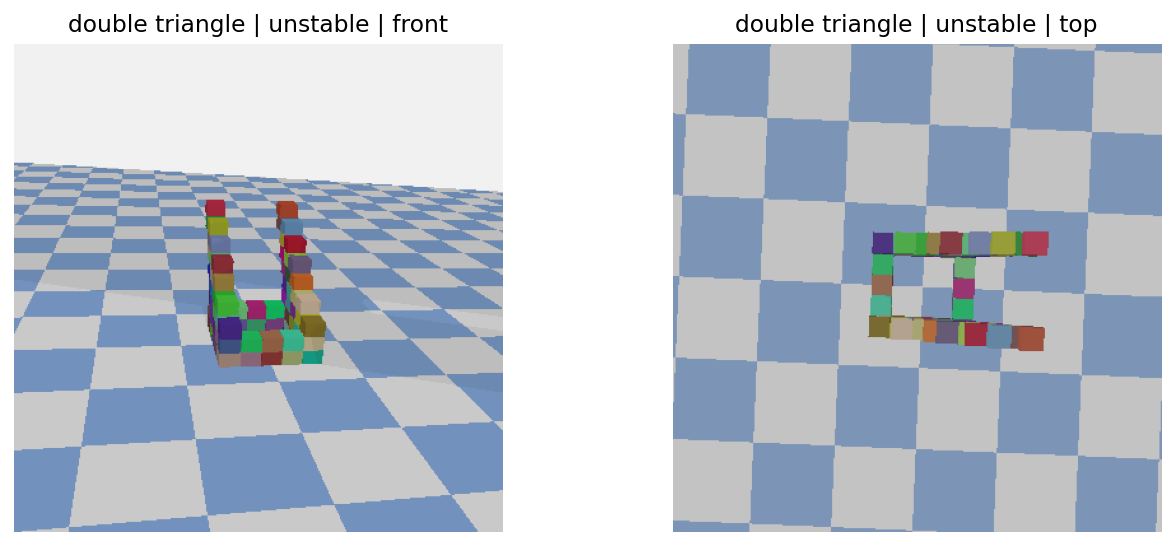

In [3]:
# Single-case sanity check
preview, front_metrics, top_metrics = preview_case('double triangle', 'unstable', seed=42)
display(pd.DataFrame([{
    **flatten_profile(preview.render_profile),
    'front_brightness_mean': front_metrics['brightness_mean'],
    'front_saturation_mean': front_metrics['saturation_mean'],
    'top_brightness_mean': top_metrics['brightness_mean'],
    'top_saturation_mean': top_metrics['saturation_mean'],
}]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(preview.front_rgb)
axes[0].set_title('double triangle | unstable | front')
axes[0].axis('off')
axes[1].imshow(preview.top_rgb)
axes[1].set_title('double triangle | unstable | top')
axes[1].axis('off')
plt.tight_layout()

,seed,front_eye_z,front_fov,light_dir_x,light_dir_y,light_dir_z,light_color,front_sat_gain,front_val_gain,front_brightness_mean,front_saturation_mean,top_brightness_mean,top_saturation_mean
0,0,3.9496,44.3369,-0.6682,0.3753,0.6424,0.8318,1.3689,0.9015,0.6743,0.2094,0.6958,0.1719
1,1,3.5158,39.6952,-0.6844,0.2352,0.6902,0.9030,1.3816,0.9259,0.7488,0.1795,0.7767,0.1708
2,2,4.3571,42.5607,-0.7739,0.3116,0.5513,0.8341,1.3485,0.9211,0.6507,0.2228,0.7220,0.1778
3,3,4.1904,43.4505,-0.8294,0.1921,0.5245,0.9390,1.2951,0.8932,0.6433,0.2003,0.6823,0.1883
4,4,4.0454,43.0548,-0.6113,0.3454,0.7120,0.9438,1.3575,0.8838,0.7040,0.1896,0.7584,0.1857
5,5,3.7514,40.8987,-0.7688,0.3159,0.5560,0.8220,1.2006,0.9560,0.7064,0.1773,0.7212,0.1788
6,6,4.4079,40.9149,-0.6387,0.3282,0.6959,0.8292,1.3787,0.9605,0.7342,0.2032,0.7408,0.1787
7,7,2.8349,39.0224,-0.6570,0.4220,0.6247,0.8911,1.2667,0.9338,0.7397,0.1680,0.6946,0.1794


,front_brightness_mean,front_saturation_mean,top_brightness_mean,top_saturation_mean
mean,0.7002,0.1938,0.7240,0.1789
std,0.0405,0.0184,0.0331,0.0060
min,0.6433,0.1680,0.6823,0.1708
max,0.7488,0.2228,0.7767,0.1883


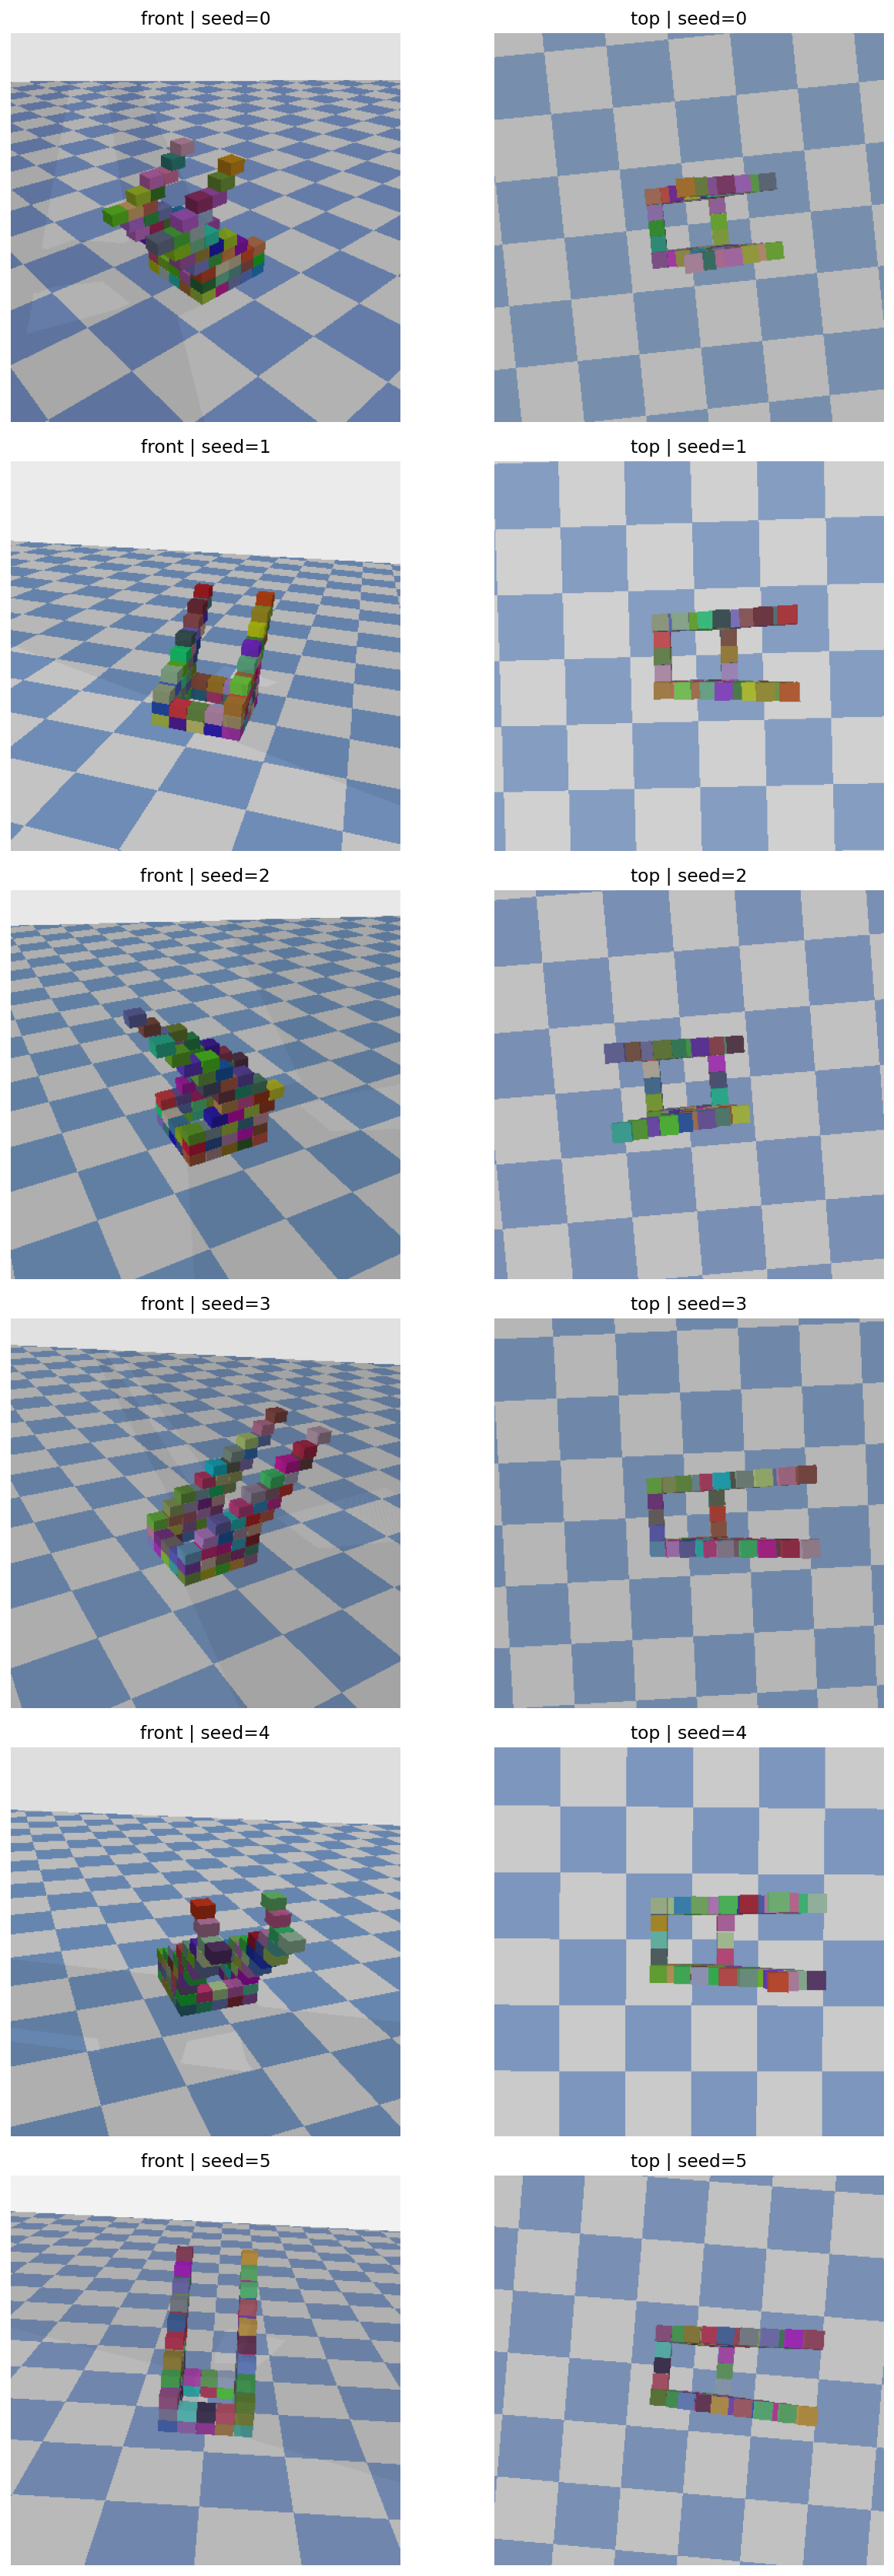

In [4]:
# Multi-seed summary for one class
summary_df, previews = summarize_cases('double triangle', 'unstable', seeds=range(8))
display(summary_df[['seed', 'front_eye_z', 'front_fov', 'light_dir_x', 'light_dir_y', 'light_dir_z', 'light_color', 'front_sat_gain', 'front_val_gain', 'front_brightness_mean', 'front_saturation_mean', 'top_brightness_mean', 'top_saturation_mean']].round(4))

display(summary_df[['front_brightness_mean', 'front_saturation_mean', 'top_brightness_mean', 'top_saturation_mean']].agg(['mean', 'std', 'min', 'max']).round(4))

show_previews(previews, max_items=6)

In [5]:
# Label-grid check: one seed per class
rows = []
for structure in CLASS_ORDER:
    for stability in ['stable', 'unstable']:
        preview, front_metrics, top_metrics = preview_case(structure, stability, seed=42)
        rows.append({
            'structure': structure,
            'stability': stability,
            'front_brightness_mean': front_metrics['brightness_mean'],
            'front_saturation_mean': front_metrics['saturation_mean'],
            'top_brightness_mean': top_metrics['brightness_mean'],
            'top_saturation_mean': top_metrics['saturation_mean'],
            'light_dir_x': preview.render_profile['light']['direction'][0],
            'light_dir_y': preview.render_profile['light']['direction'][1],
            'light_dir_z': preview.render_profile['light']['direction'][2],
        })
label_grid_df = pd.DataFrame(rows)
display(label_grid_df.round(4))

,structure,stability,front_brightness_mean,front_saturation_mean,top_brightness_mean,top_saturation_mean,light_dir_x,light_dir_y,light_dir_z
0,thin tower,stable,0.7444,0.1586,0.7291,0.1518,-0.7294,0.1843,0.6587
1,thin tower,unstable,0.7441,0.1604,0.7270,0.1532,-0.7294,0.1843,0.6587
2,thick tower,stable,0.6667,0.2003,0.7133,0.1684,-0.7318,0.4270,0.5311
3,thick tower,unstable,0.6696,0.2036,0.7090,0.1763,-0.7318,0.4270,0.5311
4,wall,stable,0.7595,0.1689,0.7611,0.1540,-0.7381,0.2463,0.6281
5,wall,unstable,0.6995,0.1606,0.6609,0.1735,-0.7799,0.3226,0.5364
6,thin triangle,stable,0.7258,0.1753,0.7201,0.1588,-0.6864,0.3985,0.6083
7,thin triangle,unstable,0.7413,0.1492,0.7201,0.1700,-0.6608,0.3712,0.6523
8,thick triangle,stable,0.7162,0.1676,0.6786,0.1631,-0.7002,0.4706,0.5368
9,thick triangle,unstable,0.6828,0.2132,0.7483,0.1912,-0.7105,0.1797,0.6804


In [6]:
# Compare sampled image metrics against eda v2 proxy targets
compare_df = pd.DataFrame([
    {'view': 'front', 'metric': 'brightness_mean', 'sample_mean': summary_df['front_brightness_mean'].mean()},
    {'view': 'front', 'metric': 'saturation_mean', 'sample_mean': summary_df['front_saturation_mean'].mean()},
    {'view': 'top', 'metric': 'brightness_mean', 'sample_mean': summary_df['top_brightness_mean'].mean()},
    {'view': 'top', 'metric': 'saturation_mean', 'sample_mean': summary_df['top_saturation_mean'].mean()},
]).merge(EDA_TARGETS, on=['view', 'metric'], how='left')
compare_df['delta'] = compare_df['sample_mean'] - compare_df['target_mean']
display(compare_df.round(4))

,view,metric,sample_mean,target_mean,notes,delta
0,front,brightness_mean,0.7002,0.826,dev/test proxy,-0.1258
1,front,saturation_mean,0.1938,0.154,dev/test proxy,0.0398
2,top,brightness_mean,0.7240,0.846,dev/test proxy,-0.1220
3,top,saturation_mean,0.1789,0.151,dev/test proxy,0.0279
